In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
import copy
import joblib 
warnings.filterwarnings('ignore')
%matplotlib inline

In [5]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

In [6]:
df = pd.read_csv("delhi_aqi_weather_daily.csv")

df.head()

,City,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI,AQI_Bucket,Temperature,Humidity,WindSpeed,WindDirection,Rain,month,day_of_week,day_of_year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,...,204.5,Severe,16.145833,68.083333,1.660000,95.708333,0.0,1,3,1
1,Delhi,2015-01-02,344.2,173.2,179.8,128.4,156.1,15.6,6.28,7.5,...,238.5,Satisfactory,15.037500,84.166667,1.600417,88.916667,3.4,1,4,2
2,Delhi,2015-01-03,473.9,20.1,12.7,102.7,244.7,42.5,0.04,29.8,...,77.6,Satisfactory,15.441667,84.000000,1.421667,276.791667,0.5,1,5,3
3,Delhi,2015-01-04,32.4,414.8,198.1,25.6,218.2,13.2,2.47,50.4,...,85.4,Satisfactory,14.162500,79.250000,2.807500,313.291667,0.0,1,6,4
4,Delhi,2015-01-05,312.8,155.8,143.1,106.8,6.1,4.9,4.04,2.0,...,396.8,Poor,13.995833,74.208333,5.365417,299.041667,0.0,1,0,5


In [7]:
df_copy = copy.deepcopy(df)

In [35]:
df_copy["year"] = df_copy["Date"].dt.year

In [9]:
df_copy["day_sin"] = np.sin(
    2*np.pi*df_copy["day_of_year"]/365
)

df_copy["day_cos"] = np.cos(
    2*np.pi*df_copy["day_of_year"]/365
)

In [36]:
df_copy["Date"] = pd.to_datetime(df_copy["Date"])

df_copy = df_copy.sort_values("Date").reset_index(drop=True)

df_copy.head()

,City,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,...,PM10_rolling_3,PM10_rolling_7,PM25_median_7,PM25_std_7,PM10_median_7,PM25_max_7,PM10_max_7,Target_PM25,Target_PM10,year
0,Delhi,2015-01-31,405.9,355.9,116.2,88.1,125.4,26.6,6.87,87.6,...,313.700000,424.928571,336.2,167.772313,457.0,485.5,576.0,4.2,172.2,2015
1,Delhi,2015-02-01,4.2,172.2,85.1,0.9,146.2,47.1,2.99,91.0,...,218.700000,384.242857,125.9,185.693497,443.0,485.5,576.0,334.2,286.2,2015
2,Delhi,2015-02-02,334.2,286.2,108.7,139.7,54.2,32.4,2.99,14.9,...,271.433333,342.842857,125.9,185.488155,355.9,485.5,557.4,292.7,5.6,2015
3,Delhi,2015-02-03,292.7,5.6,160.1,110.9,97.6,34.1,4.79,49.8,...,154.666667,280.357143,292.7,181.956019,286.2,485.5,557.4,413.1,254.3,2015
4,Delhi,2015-02-04,413.1,254.3,156.9,44.4,239.4,23.1,5.08,39.5,...,182.033333,237.057143,334.2,172.463198,254.3,485.5,457.2,172.9,328.3,2015


#### Season Features

In [11]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8,9]:
        return "Monsoon"

    else:
        return "Autumn"


df_copy["Season"] = df_copy["month"].apply(get_season)

df_copy = pd.get_dummies(
    df_copy,
    columns=["Season"],
    drop_first=True
)

##### Lag features

In [12]:
# PM2.5

df_copy["PM25_lag1"] = df_copy["PM25"].shift(1)   # PM2.5 of yesterday
df_copy["PM25_lag3"] = df_copy["PM25"].shift(3)   # PM2.5 3 days ago
df_copy["PM25_lag7"] = df_copy["PM25"].shift(7)   # PM2.5 1 week ago

# PM10

df_copy["PM10_lag1"] = df_copy["PM10"].shift(1)    # PM10 of yesterday
df_copy["PM10_lag3"] = df_copy["PM10"].shift(3)    # PM10 3 days ago
df_copy["PM10_lag7"] = df_copy["PM10"].shift(7)    # PM10 1 week ago

In [13]:
df_copy["PM25_lag14"] = df_copy["PM25"].shift(14) 

In [14]:
df_copy["PM25_lag30"] = df_copy["PM25"].shift(30)

In [15]:
df_copy["PM10_lag14"] = df_copy["PM10"].shift(14)

df_copy["PM10_lag30"] = df_copy["PM10"].shift(30)

##### Rolling features

In [17]:
df_copy["PM25_rolling_3"] = df_copy["PM25"].rolling(3).mean()
df_copy["PM25_rolling_7"] = df_copy["PM25"].rolling(7).mean()

In [18]:
df_copy["PM10_rolling_3"] = df_copy["PM10"].rolling(3).mean()
df_copy["PM10_rolling_7"] = df_copy["PM10"].rolling(7).mean()

In [19]:
df_copy["PM25_median_7"] = (
    df_copy["PM25"]
    .rolling(7)
    .median()
)

In [20]:
df_copy["PM25_std_7"] = (
    df_copy["PM25"]
     .rolling(7)
      .std()
)


In [21]:
df_copy["PM10_median_7"] = (
    df_copy["PM10"]
    .rolling(7)
    .median()
)

In [22]:
df_copy["PM25_max_7"] = (
    df_copy["PM25"]
    .rolling(7)
    .max()
)

In [23]:
df_copy["PM10_max_7"] = (
    df_copy["PM10"]
    .rolling(7)
    .max()
)

##### Lag features and rolling features create NaN values

In [24]:
df_copy = df_copy.dropna().reset_index(drop=True)

In [25]:
df_copy["Target_PM25"] = df_copy["PM25"].shift(-1)
df_copy["Target_PM10"] = df_copy["PM10"].shift(-1)

df_copy = df_copy.dropna().reset_index(drop=True)

print(df_copy.shape)

df_copy.head()

(3602, 50)


,City,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,...,PM25_rolling_7,PM10_rolling_3,PM10_rolling_7,PM25_median_7,PM25_std_7,PM10_median_7,PM25_max_7,PM10_max_7,Target_PM25,Target_PM10
0,Delhi,2015-01-31,405.9,355.9,116.2,88.1,125.4,26.6,6.87,87.6,...,277.171429,313.700000,424.928571,336.2,167.772313,457.0,485.5,576.0,4.2,172.2
1,Delhi,2015-02-01,4.2,172.2,85.1,0.9,146.2,47.1,2.99,91.0,...,221.014286,218.700000,384.242857,125.9,185.693497,443.0,485.5,576.0,334.2,286.2
2,Delhi,2015-02-02,334.2,286.2,108.7,139.7,54.2,32.4,2.99,14.9,...,220.728571,271.433333,342.842857,125.9,185.488155,355.9,485.5,557.4,292.7,5.6
3,Delhi,2015-02-03,292.7,5.6,160.1,110.9,97.6,34.1,4.79,49.8,...,244.557143,154.666667,280.357143,292.7,181.956019,286.2,485.5,557.4,413.1,254.3
4,Delhi,2015-02-04,413.1,254.3,156.9,44.4,239.4,23.1,5.08,39.5,...,293.985714,182.033333,237.057143,334.2,172.463198,254.3,485.5,457.2,172.9,328.3


In [26]:
print(df_copy["Target_PM25"].describe())

count    3602.000000
mean      253.005497
std       141.815675
min         0.200000
25%       130.400000
50%       255.400000
75%       374.250000
max       499.800000
Name: Target_PM25, dtype: float64


In [27]:
df_copy[["Date","PM25","Target_PM25"]].head(10)

,Date,PM25,Target_PM25
0,2015-01-31,405.9,4.2
1,2015-02-01,4.2,334.2
2,2015-02-02,334.2,292.7
3,2015-02-03,292.7,413.1
4,2015-02-04,413.1,172.9
5,2015-02-05,172.9,23.8
6,2015-02-06,23.8,207.1
7,2015-02-07,207.1,21.0
8,2015-02-08,21.0,476.6
9,2015-02-09,476.6,262.9


In [28]:
df_copy[["Date","PM25"]].head(20)

,Date,PM25
0,2015-01-31,405.9
1,2015-02-01,4.2
2,2015-02-02,334.2
3,2015-02-03,292.7
4,2015-02-04,413.1
5,2015-02-05,172.9
6,2015-02-06,23.8
7,2015-02-07,207.1
8,2015-02-08,21.0
9,2015-02-09,476.6


In [29]:
df_copy[["Date","PM25"]].tail(20)

,Date,PM25
3582,2024-11-21,317.8
3583,2024-11-22,404.9
3584,2024-11-23,478.3
3585,2024-11-24,123.6
3586,2024-11-25,120.2
3587,2024-11-26,186.9
3588,2024-11-27,133.9
3589,2024-11-28,409.3
3590,2024-11-29,168.4
3591,2024-11-30,308.5


In [30]:
df_copy.shape

(3602, 50)

In [31]:
df_copy.select_dtypes(include=['number']).corr()["Target_PM25"].sort_values()

Target_PM10      -0.023908
PM10_lag7        -0.022214
PM10_lag1        -0.018788
Benzene          -0.018546
Humidity         -0.014431
day_cos          -0.012513
PM10_median_7    -0.010493
PM25_std_7       -0.010455
PM10_lag30       -0.008189
PM25_lag3        -0.007299
PM10_rolling_3   -0.005814
PM25_lag1        -0.004449
PM25_lag7        -0.003670
CO               -0.003381
day_of_week      -0.003153
PM25             -0.002972
PM10_rolling_7   -0.002221
Rain             -0.002214
PM10_lag14       -0.001968
PM25_max_7       -0.001058
day_sin          -0.000803
PM25_rolling_3    0.000012
PM10              0.000935
Xylene            0.001382
PM10_lag3         0.001445
NO                0.002044
PM25_lag14        0.002260
PM10_max_7        0.002830
O3                0.005689
AQI               0.007729
NOx               0.007872
SO2               0.008506
NO2               0.013503
PM25_rolling_7    0.014235
PM25_median_7     0.014357
Temperature       0.016324
month             0.017623
d

In [32]:
print(df_copy.shape)

print(df_copy.columns.tolist())

(3602, 50)
['City', 'Date', 'PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Temperature', 'Humidity', 'WindSpeed', 'WindDirection', 'Rain', 'month', 'day_of_week', 'day_of_year', 'day_sin', 'day_cos', 'Season_Monsoon', 'Season_Summer', 'Season_Winter', 'PM25_lag1', 'PM25_lag3', 'PM25_lag7', 'PM10_lag1', 'PM10_lag3', 'PM10_lag7', 'PM25_lag14', 'PM25_lag30', 'PM10_lag14', 'PM10_lag30', 'PM25_rolling_3', 'PM25_rolling_7', 'PM10_rolling_3', 'PM10_rolling_7', 'PM25_median_7', 'PM25_std_7', 'PM10_median_7', 'PM25_max_7', 'PM10_max_7', 'Target_PM25', 'Target_PM10']


#### `feature set`

In [55]:
feature_cols = [
    # Current pollutant features
    "PM25",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",

    # Weather features
    "Temperature",
    "Humidity",
    "WindSpeed",
    "WindDirection",
    "Rain",

    # PM2.5 lag features
    "PM25_lag1",
    "PM25_lag3",
    "PM25_lag7",
    "PM25_lag14",
    "PM25_lag30",

    # PM10 lag features
    "PM10_lag1",
    "PM10_lag3",
    "PM10_lag7",
    "PM10_lag14",
    "PM10_lag30",

    # PM2.5 rolling features
    "PM25_rolling_3",
    "PM25_rolling_7",
    "PM25_median_7",
    "PM25_max_7",
    "PM25_std_7",

    # PM10 rolling features
    "PM10_rolling_3",
    "PM10_rolling_7",
    "PM10_median_7",
    "PM10_max_7",

    # Time features
    "year",
    "month",
    "day_of_week",
    "day_of_year",
    "day_sin",
    "day_cos",

    # Season features
    "Season_Monsoon",
    "Season_Summer",
    "Season_Winter"
]
   

X = df_copy[feature_cols]

y_pm25 = df_copy["Target_PM25"]
y_pm10 = df_copy["Target_PM10"]

print(X.shape)

(3602, 45)


#### Time-based train/test split

In [56]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [57]:
split = int(len(df_copy) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_pm25_train = y_pm25.iloc[:split]
y_pm25_test = y_pm25.iloc[split:]

y_pm10_train = y_pm10.iloc[:split]
y_pm10_test = y_pm10.iloc[split:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (2881, 45)
Test : (721, 45)


### Train PM2.5 model

In [39]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [59]:
param_dist = {
    "n_estimators": [200, 300, 500, 700, 1000],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "max_depth": [3, 4, 5, 6, 8],

    "min_child_weight": [1, 3, 5, 7],

    "subsample": [0.6, 0.8, 1.0],

    "colsample_bytree": [0.6, 0.8, 1.0],

    "gamma": [0, 0.1, 0.3, 0.5],

    "reg_alpha": [0, 0.01, 0.1, 1],

    "reg_lambda": [1, 2, 5]
}

In [68]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,

    n_iter=30,          # good balance between speed and quality

    scoring="neg_root_mean_squared_error",

    cv=tscv,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

### Fit model

In [69]:
random_search.fit(X_train, y_pm25_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estima

In [70]:
print(random_search.best_params_)

{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [71]:
best_model = random_search.best_estimator_

### Prediction

In [72]:
y_pred_best = best_model.predict(X_test)

### Evaluation

In [75]:
mae = mean_absolute_error(y_pm25_test, y_pred_best)

rmse = np.sqrt(mean_squared_error(y_pm25_test, y_pred_best))

r2 = r2_score(y_pm25_test, y_pred_best)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 121.61
RMSE : 141.37
R²   : -0.0166


In [ ]:
baseline_pred = X_test["PM25"]

print("Baseline MAE :", mean_absolute_error(y_pm25_test, baseline_pred))

print(
    "Baseline RMSE:",
    np.sqrt(mean_squared_error(y_pm25_test, baseline_pred))
)

print("Baseline R2  :", r2_score(y_pm25_test, baseline_pred))

Baseline MAE : 161.62773925104023
Baseline RMSE: 197.14388044720246
Baseline R2  : -0.9769639457543982


### Actual vs Predicted

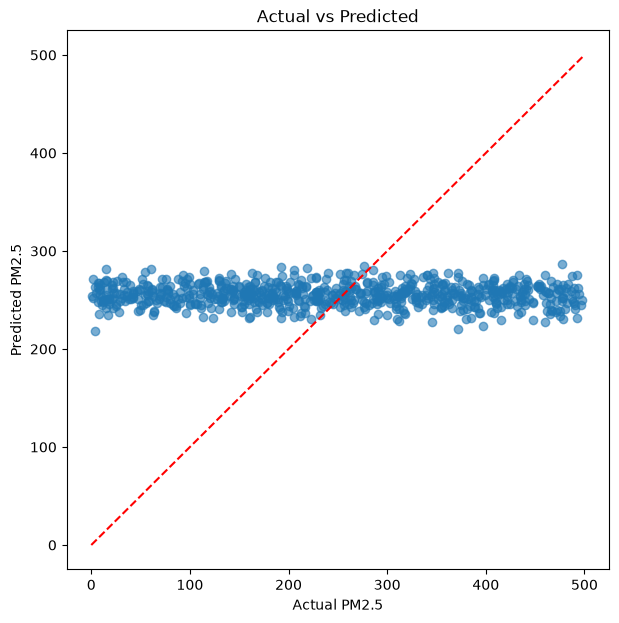

In [90]:
plt.figure(figsize=(7,7))
plt.scatter(y_pm25_test, y_pred_best, alpha=0.6)

plt.plot(
    [0, 500],
    [0, 500],
    "r--"
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")

plt.show()

In [101]:
comparison = pd.DataFrame({
    "Actual": y_pm25_test.values,
    "Predicted": y_pred_best
})

comparison.head(8)

,Actual,Predicted
0,236.9,257.925049
1,411.8,255.699936
2,170.1,247.548584
3,455.0,261.277649
4,468.5,262.838226
5,439.3,244.985352
6,272.2,256.219666
7,293.9,262.768433


### Saving `PM2.5` model

In [ ]:
joblib.dump(best_model, "pm25_xgboost_model.pkl")
print("model saved successfully")

model saved successfully


#### saving feature list

In [109]:
joblib.dump(feature_cols, "pm25_features.pkl")

['pm25_features.pkl']

#### saving metadata

In [110]:
metadata = {
    "target": "Target_PM25",
    "model": "XGBoost",
    "train_size": len(X_train),
    "test_size": len(X_test),
    "MAE": 121.61,
    "RMSE": 141.37,
    "R2": -0.0166
}

joblib.dump(metadata, "pm25_metadata.pkl")

['pm25_metadata.pkl']